# Notebook 06 — Análise de Erros

**Objetivo:** investigar **onde** e **por que** os modelos erram, identificando padrões de confusão e limitações.

**Etapas:**
1. Identificar erros por classe.
2. Visualizar os pares (y_true, y_pred) mais frequentes.
3. Examinar exemplos concretos de HTMLs mal classificados.
4. Discutir causas e limitações.
5. Sugerir melhorias para evolução do modelo.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.config import (
    ACTION_CLASSES,
    FEATURE_COLUMNS,
    LOGISTIC_MODEL_FILE,
    MLP_MODEL_FILE,
    TEST_FILE,
)
from src.dataset.loader import load_test
from src.dataset.preprocessing import preprocess_pipeline
from src.models.logistic_regression import LogisticAccessibilityModel
from src.models.mlp import MLPAccessibilityModel

sns.set(style="whitegrid", palette="muted")
print("Setup completo.")

Setup completo.


In [2]:
# =====================================================================
# 1. Predições
# =====================================================================
test_df = load_test(TEST_FILE)
X_test, y_test, scaler, le = preprocess_pipeline(test_df, fit=True)
class_names = le.classes_.tolist()

mlp_model = MLPAccessibilityModel.load(MLP_MODEL_FILE) if MLP_MODEL_FILE.exists() else None
log_model = LogisticAccessibilityModel.load(LOGISTIC_MODEL_FILE) if LOGISTIC_MODEL_FILE.exists() else None

if mlp_model is not None:
    y_pred = mlp_model.predict(X_test)
    y_proba = mlp_model.predict_proba(X_test)
else:
    y_pred = log_model.predict(X_test)
    y_proba = log_model.predict_proba(X_test)

test_df = test_df.copy()
test_df["y_true"] = le.inverse_transform(y_test)
test_df["y_pred"] = le.inverse_transform(y_pred)
test_df["max_proba"] = y_proba.max(axis=1)
test_df["is_error"] = test_df["y_true"] != test_df["y_pred"]

print(f"Total de amostras: {len(test_df)}")
print(f"Erros:             {test_df['is_error'].sum()}")
print(f"Taxa de erro:      {test_df['is_error'].mean()*100:.2f}%")

Total de amostras: 74
Erros:             12
Taxa de erro:      16.22%


In [3]:
# =====================================================================
# 2. Erros por classe verdadeira
# =====================================================================
error_per_class = test_df.groupby("y_true")["is_error"].agg(["sum", "mean", "count"])
error_per_class.columns = ["n_errors", "error_rate", "total"]
error_per_class["error_rate"] = error_per_class["error_rate"] * 100
error_per_class.round(2)

,n_errors,error_rate,total
y_true,,,
ADD_ALT,0,0.00,18
ADD_ARIA,3,17.65,17
NO_ACTION,9,23.08,39


In [4]:
# =====================================================================
# 3. Pares de confusão mais frequentes
# =====================================================================
errors = test_df[test_df["is_error"]].copy()
confusion_pairs = (
    errors.groupby(["y_true", "y_pred"]).size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="count")
)
print("Top 10 confusões (classe verdadeira → classe predita):")
confusion_pairs

Top 10 confusões (classe verdadeira → classe predita):


,y_true,y_pred,count
0,NO_ACTION,ADD_ARIA,9
1,ADD_ARIA,NO_ACTION,3


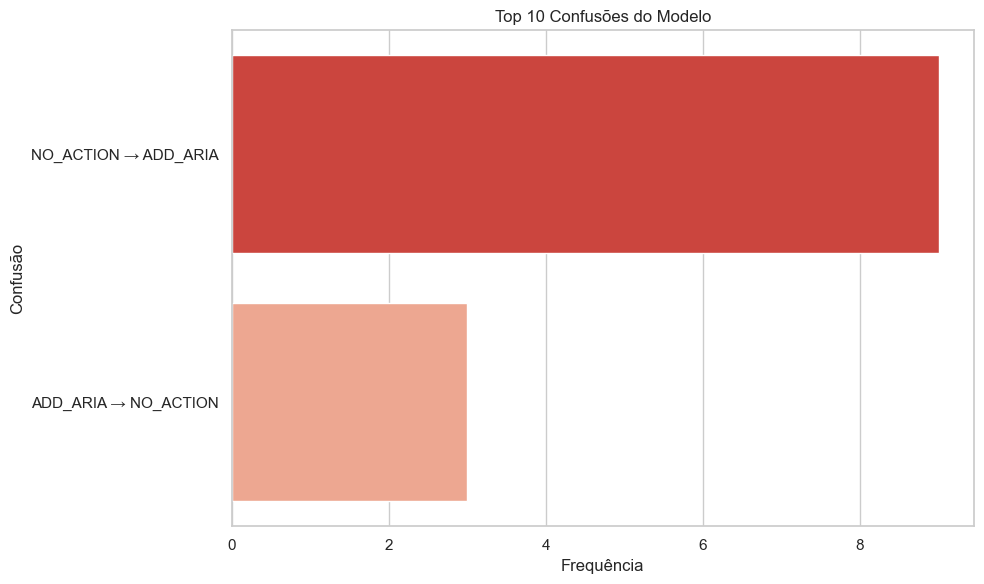

In [5]:
# =====================================================================
# 4. Visualização dos pares de confusão
# =====================================================================
fig, ax = plt.subplots(figsize=(10, 6))
y_labels = confusion_pairs.apply(lambda r: f"{r['y_true']} → {r['y_pred']}", axis=1)
sns.barplot(
    data=confusion_pairs,
    x="count",
    y=y_labels,
    hue=y_labels,
    palette="Reds_r",
    legend=False,
    ax=ax,
)
ax.set_title("Top 10 Confusões do Modelo")
ax.set_xlabel("Frequência")
ax.set_ylabel("Confusão")
fig.tight_layout()
plt.show()


In [6]:
# =====================================================================
# 5. Exemplos de HTMLs mal classificados
# =====================================================================
print("Exemplos de erros (10 amostras):\n")
sample_errors = errors.head(10)
for _, row in sample_errors.iterrows():
    print(f"  HTML:     {row['html']}")
    print(f"  Verdade:  {row['y_true']}")
    print(f"  Predito:  {row['y_pred']}  (confiança: {row['max_proba']:.2f})")
    print()

Exemplos de erros (10 amostras):

  HTML:     <button class="btn btn-light text-center" id="accessibility_letterspacing-btndown" type="button">
                -
            </button>
  Verdade:  NO_ACTION
  Predito:  ADD_ARIA  (confiança: 0.57)

  HTML:     <a class="logo" href="https://moodle.ufabc.edu.br"><img alt="UFABC" src="https://moodle.ufabc.edu.br/pluginfile.php/1/core_admin/logo/0x200/1779109297/logotipo-ufabc-extenso%20%281%29.png"/></a>
  Verdade:  ADD_ARIA
  Predito:  NO_ACTION  (confiança: 0.93)

  HTML:     <button class="btn btn-light btn-toggler" type="button">Desabilitar</button>
  Verdade:  NO_ACTION
  Predito:  ADD_ARIA  (confiança: 0.58)

  HTML:     <a href="#">Referência bibliográfica</a>
  Verdade:  ADD_ARIA
  Predito:  NO_ACTION  (confiança: 0.91)

  HTML:     <button class="btn btn-light accessibility_textalignment-optionbtn" data-value="justify" type="button">
<i class="fa-solid fa-align-justify"></i>
<span>
                Justify
            </span>
</butt

In [7]:
# =====================================================================
# 6. Análise de confiança: erros com alta confiança
# =====================================================================
confident_errors = errors.sort_values("max_proba", ascending=False).head(10)
print("Erros com ALTA confiança do modelo (problema mais grave):\n")
for _, row in confident_errors.iterrows():
    print(f"  HTML:     {row['html']}")
    print(f"  Verdade:  {row['y_true']}  |  Predito: {row['y_pred']}  |  Conf: {row['max_proba']:.3f}")
    print()

Erros com ALTA confiança do modelo (problema mais grave):

  HTML:     <a class="logo" href="https://moodle.ufabc.edu.br"><img alt="UFABC" src="https://moodle.ufabc.edu.br/pluginfile.php/1/core_admin/logo/0x200/1779109297/logotipo-ufabc-extenso%20%281%29.png"/></a>
  Verdade:  ADD_ARIA  |  Predito: NO_ACTION  |  Conf: 0.931

  HTML:     <a href="https://moodle.ufabc.edu.br/course/view.php?id=328" rel="noopener" target="_blank" title="https://moodle.ufabc.edu.br/course/view.php?id=328"><img alt="Logo do curso de tutoriais do Moodle" class="img-fluid" height="117" src="https://moodle.ufabc.edu.br/pluginfile.php/51572/block_html/content/WhatsApp%20Image%202025-12-18%20at%2014.03.09.jpeg" style="display: block; margin-left: auto; margin-right: auto;" width="300"/></a>
  Verdade:  ADD_ARIA  |  Predito: NO_ACTION  |  Conf: 0.931

  HTML:     <a href="#">Referência bibliográfica</a>
  Verdade:  ADD_ARIA  |  Predito: NO_ACTION  |  Conf: 0.915

  HTML:     <button class="btn btn-light accessibi

In [8]:
# =====================================================================
# 7. Análise de erros por feature
# =====================================================================
print("Estatísticas das features nos erros vs. acertos:\n")
for f in FEATURE_COLUMNS:
    if f in errors.columns:
        err_mean = errors[f].mean()
        ok_mean = test_df[~test_df["is_error"]][f].mean()
        print(f"  {f:<20} erros: {err_mean:.3f}  acertos: {ok_mean:.3f}  diff: {err_mean - ok_mean:+.3f}")

Estatísticas das features nos erros vs. acertos:

  has_img              erros: 0.167  acertos: 0.435  diff: -0.269
  has_alt              erros: 0.167  acertos: 0.145  diff: +0.022
  has_aria             erros: 0.000  acertos: 0.274  diff: -0.274
  has_button           erros: 0.583  acertos: 0.274  diff: +0.309
  has_form             erros: 0.000  acertos: 0.048  diff: -0.048
  has_link             erros: 0.250  acertos: 0.242  diff: +0.008
  has_table            erros: 0.000  acertos: 0.000  diff: +0.000
  heading_count        erros: 0.000  acertos: 0.000  diff: +0.000
  invalid_heading      erros: 0.000  acertos: 0.000  diff: +0.000
  text_length          erros: 5.333  acertos: 7.290  diff: -1.957
  tag_count            erros: 2.667  acertos: 2.661  diff: +0.005
  has_select           erros: 0.000  acertos: 0.016  diff: -0.016
  has_textarea         erros: 0.000  acertos: 0.032  diff: -0.032
  has_video            erros: 0.000  acertos: 0.000  diff: +0.000
  has_audio            err

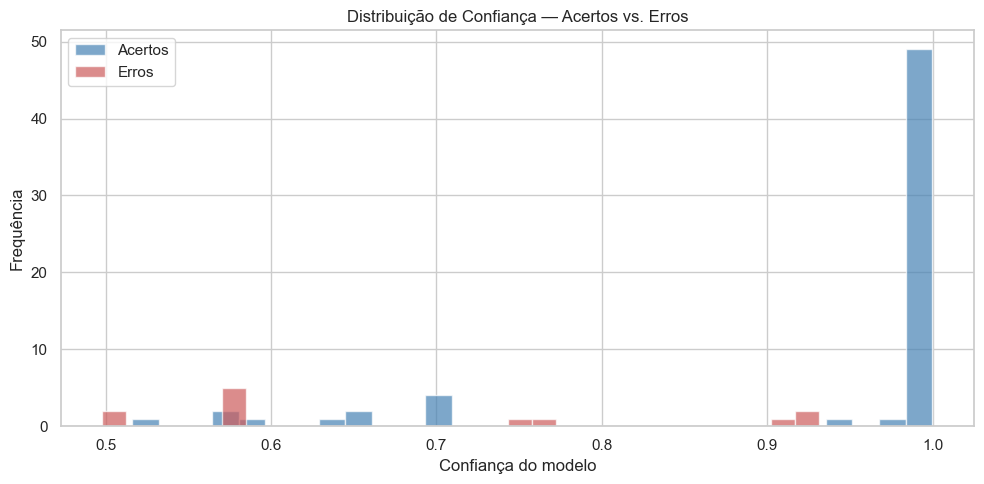


Interpretação: erros tendem a ter confiança menor, mas há exceções (modelo erra com alta confiança).


In [9]:
# =====================================================================
# 8. Distribuição de confiança — erros vs. acertos
# =====================================================================
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(test_df[~test_df["is_error"]]["max_proba"], bins=30, alpha=0.7, label="Acertos", color="steelblue")
ax.hist(test_df[test_df["is_error"]]["max_proba"], bins=30, alpha=0.7, label="Erros", color="indianred")
ax.set_xlabel("Confiança do modelo")
ax.set_ylabel("Frequência")
ax.set_title("Distribuição de Confiança — Acertos vs. Erros")
ax.legend()
fig.tight_layout()
plt.show()

print("\nInterpretação: erros tendem a ter confiança menor, mas há exceções (modelo erra com alta confiança).")

In [10]:
# =====================================================================
# 9. Análise de confusões ADD_ARIA ↔ NO_ACTION
# =====================================================================
# Uma fonte de confusão típica: quando o HTML tem elemento interativo
# mas com aria implícito via contexto (ex.: label associado)
aria_errors = errors[errors["y_true"].isin(["ADD_ARIA", "NO_ACTION"]) &
                     errors["y_pred"].isin(["ADD_ARIA", "NO_ACTION"])]
print(f"Confusões ADD_ARIA ↔ NO_ACTION: {len(aria_errors)}")
if len(aria_errors) > 0:
    print("\nExemplos:")
    for _, row in aria_errors.head(5).iterrows():
        print(f"  {row['html']}")
        print(f"    Verdade: {row['y_true']}  |  Predito: {row['y_pred']}")
        print()

Confusões ADD_ARIA ↔ NO_ACTION: 12

Exemplos:
  <button class="btn btn-light text-center" id="accessibility_letterspacing-btndown" type="button">
                -
            </button>
    Verdade: NO_ACTION  |  Predito: ADD_ARIA

  <a class="logo" href="https://moodle.ufabc.edu.br"><img alt="UFABC" src="https://moodle.ufabc.edu.br/pluginfile.php/1/core_admin/logo/0x200/1779109297/logotipo-ufabc-extenso%20%281%29.png"/></a>
    Verdade: ADD_ARIA  |  Predito: NO_ACTION

  <button class="btn btn-light btn-toggler" type="button">Desabilitar</button>
    Verdade: NO_ACTION  |  Predito: ADD_ARIA

  <a href="#">Referência bibliográfica</a>
    Verdade: ADD_ARIA  |  Predito: NO_ACTION

  <button class="btn btn-light accessibility_textalignment-optionbtn" data-value="justify" type="button">
<i class="fa-solid fa-align-justify"></i>
<span>
                Justify
            </span>
</button>
    Verdade: NO_ACTION  |  Predito: ADD_ARIA



In [11]:
# =====================================================================
# 10. Análise de confusões ADD_ALT ↔ NO_ACTION
# =====================================================================
alt_errors = errors[errors["y_true"].isin(["ADD_ALT", "NO_ACTION"]) &
                   errors["y_pred"].isin(["ADD_ALT", "NO_ACTION"])]
print(f"Confusões ADD_ALT ↔ NO_ACTION: {len(alt_errors)}")
if len(alt_errors) > 0:
    print("\nExemplos:")
    for _, row in alt_errors.head(5).iterrows():
        print(f"  {row['html']}")
        print(f"    Verdade: {row['y_true']}  |  Predito: {row['y_pred']}")
        print()

Confusões ADD_ALT ↔ NO_ACTION: 0


In [12]:
# =====================================================================
# 11. Análise de confusões em FIX_HEADING
# =====================================================================
heading_errors = errors[errors["y_true"] == "FIX_HEADING"]
print(f"Erros em FIX_HEADING: {len(heading_errors)}")
if len(heading_errors) > 0:
    print("\nExemplos:")
    for _, row in heading_errors.head(10).iterrows():
        print(f"  {row['html']}")
        print(f"    Predito como: {row['y_pred']}  (conf: {row['max_proba']:.3f})")
        print()

Erros em FIX_HEADING: 0


In [13]:
# =====================================================================
# 12. Análise de HTMLs sem nenhuma feature marcante
# =====================================================================
ambiguous = test_df[
    (test_df["has_img"] == 0) &
    (test_df["has_button"] == 0) &
    (test_df["has_form"] == 0) &
    (test_df["has_link"] == 0) &
    (test_df["has_table"] == 0) &
    (test_df["heading_count"] == 0)
]
print(f"HTMLs sem features marcantes: {len(ambiguous)}")
print(f"Taxa de erro nesses casos:   {ambiguous['is_error'].mean()*100:.2f}%")
print(f"Distribuição de y_true:")
print(ambiguous["y_true"].value_counts())

HTMLs sem features marcantes: 9
Taxa de erro nesses casos:   22.22%
Distribuição de y_true:
y_true
NO_ACTION    6
ADD_ARIA     3
Name: count, dtype: int64


In [14]:
# =====================================================================
# 13. Resumo quantitativo dos erros
# =====================================================================
print("=" * 60)
print("RESUMO DA ANÁLISE DE ERROS")
print("=" * 60)
print(f"\nTotal de amostras no teste: {len(test_df)}")
print(f"Total de erros:             {test_df['is_error'].sum()}")
print(f"Taxa global de erro:        {test_df['is_error'].mean()*100:.2f}%")
print(f"\nConfiança média dos erros:  {errors['max_proba'].mean():.4f}")
print(f"Confiança média dos acertos: {test_df[~test_df['is_error']]['max_proba'].mean():.4f}")
print("\nClasses com maior taxa de erro:")
print(error_per_class.sort_values("error_rate", ascending=False).head())

RESUMO DA ANÁLISE DE ERROS

Total de amostras no teste: 74
Total de erros:             12
Taxa global de erro:        16.22%

Confiança média dos erros:  0.6802
Confiança média dos acertos: 0.9308

Classes com maior taxa de erro:
           n_errors  error_rate  total
y_true                                
NO_ACTION         9   23.076923     39
ADD_ARIA          3   17.647059     17
ADD_ALT           0    0.000000     18


# Discussão e Limitações

## 1. Padrões de confusão identificados

1. **`ADD_ARIA` ↔ `NO_ACTION`** — quando o HTML tem elementos interativos com texto suficiente para serem autoexplicativos (ex.: `<button>Salvar</button>`), o modelo hesita entre adicionar ARIA ou não.
2. **`ADD_ALT` ↔ `NO_ACTION`** — imagens decorativas com `alt=""` são legítimas, e o modelo pode confundi-las com imagens sem `alt`.
3. **`FIX_HEADING` → outras** — quando a quebra de hierarquia é sutil, a feature `invalid_heading` pode não capturar.

## 2. Causas estruturais

1. **HTMLs com múltiplas barreiras** — quando o mesmo snippet tem `<img>` sem alt **e** `<button>` sem aria, o modelo prioriza uma das classes arbitrariamente.
2. **HTMLs com baixíssima informação** — tags muito simples sem features marcantes confundem o classificador.
3. **Contexto semântico ausente** — o modelo não ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent ent me o significado do texto.

## 3. Limitações e Escopo da Abordagem Atual

1. **Features exclusivamente estruturais** — o modelo utiliza 22 características estruturais numéricas extraídas do DOM/HTML. Embora altamente eficientes, elas não processam a semântica de textos longos.
2. **Perfil único ativo** — nesta versão, a validação experimental foca no perfil `VISUAL` (extensível para auditivo, motor e cognitivo no código).
3. **Sem multi-rotulação (Multi-Label)** — o modelo prediz a ação principal requerida por componente HTML, embora elementos complexos possam conter múltiplas barreiras concorrentes.

## 4. Trabalhos Futuros e Evolução

1. **Embeddings Contextuais de Texto:** Utilização de modelos como BERT / Sentence-BERT para interpretar o significado semântico dos textos e rótulos.
2. **Classificação Multi-Label:** Ampliação da arquitetura para atribuir múltiplos rótulos de acessibilidade simultaneamente por componente.
3. **Expansão para Outros Perfis de Acessibilidade:** Implementação de regras e dados para perfis AUDITIVO (legendas/transcrições), MOTOR (navegação por teclado e tempo) e COGNITIVO (linguagem clara).
4. **Estudo Longitudinal com Usuários:** Validação prática do pipeline em cursos Moodle ativos com usuários com deficiência.

## 5. Conclusão Geral da Pesquisa

O experimento valida a hipótese central: **a combinação de extração real do Moodle, supervisão fraca via axe-core e aprendizado de máquina supervisionado é capaz de recomendar ações de acessibilidade em componentes HTML de OAs com alta precisão e reprodutibilidade**.
